<a href="https://colab.research.google.com/github/Nelfiguera/TPF-DATA-ANALYTICS-COMISION_26109.github.io/blob/main/EntregaFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

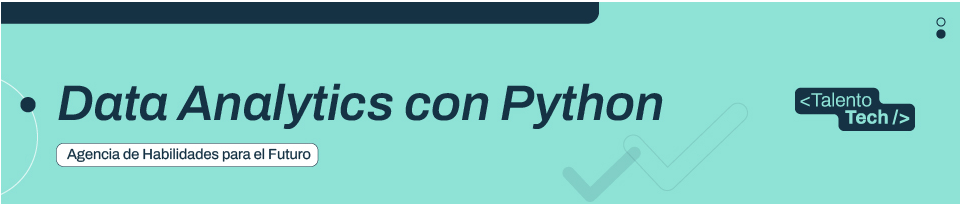


#TRABAJO PRÁCTICO INTEGRADOR DATA ANALYTICS 2026

---



# Estudiante: Nelson Figuera Castro - Comisión: 26109

# ETAPA 1: Recopilación y Preparación de Datos (Clases 1 a 4)

### 1_1- Cargar los set de datos como Dataframes

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
def cargar_dataset(link):
  # Usamos regex para extraer el file_id del link
  file_id = link.split('/d/')[1].split('/')[0]

  # Con ese file_id generamos la url
  url = f"https://drive.google.com/uc?id={file_id}"

  # Finalmente lo importamos usando el método read_csv() con la url generada, para convertirlo en dataframe.
  df = pd.read_csv(url)
  return df

### dataset clientes

In [3]:
# Link generado al compartir el archivo clientes.csv
link = "https://drive.google.com/file/d/1ucN9-zl6tXkSEyyLx2gvLmgvBxaFCEL4/view?usp=drive_link"

df_cli = cargar_dataset(link)
df_cli.head(3)

,id_cliente,nombre,edad,ciudad,ingresos
0,1,Aloysia Screase,44,Mar del Plata,42294.68
1,2,Kristina Scaplehorn,25,Posadas,24735.04
2,3,Filip Castagne,50,Resistencia,35744.85


### dataset ventas

In [4]:
# Link generado al compartir el archivo ventas.csv
link = "https://drive.google.com/file/d/1LMApZjb6q61R0XDTBMdzQmOm8W0BNl_Y/view?usp=drive_link"

df_ven = cargar_dataset(link)
df_ven.head(3)

,id_venta,producto,precio,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,$69.94,5.0,02/01/2024,Decoración
1,811,Lámpara de mesa,$105.10,5.0,02/01/2024,Decoración
2,1156,Secadora,$97.96,3.0,02/01/2024,Electrodomésticos


### dataset marketing

In [5]:
# Link generado al compartir el archivo marketing.scv
link = "https://drive.google.com/file/d/1XOwDakUmKb6sSLgUDVvKPL8jv4cVLN2H/view?usp=drive_link"

df_mar = cargar_dataset(link)
df_mar.head(3)

,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
0,74,Adorno de pared,TV,4.81,20/03/2024,03/05/2024
1,12,Tablet,RRSS,3.40,26/03/2024,13/05/2024
2,32,Lámpara de mesa,Email,5.54,28/03/2024,20/04/2024


##1-2-Realizar un script básico que calcule las ventas mensuales utilizando variables y operadores.
Script básico para calcular ventas mensuales con variables y operadores.
Este script simula un cálculo básico utilizando tipos de datos primitivos de Python para proyectar o calcular un total basándose en variables operacionales estándar.

In [6]:
# Variables iniciales de simulación.
total_ventas_historicas = 150000.50  # Float
meses_operacion = 12                 # Integer
meta_crecimiento_porcentaje = 15.0   # Porcentaje de crecimiento esperado para el próximo mes

# Operadores aritméticos básicos.
promedio_ventas_mensual = total_ventas_historicas / meses_operacion
proyeccion_proximo_mes = promedio_ventas_mensual * (1 + (meta_crecimiento_porcentaje / 100))

# Mostrar resultados utilizando strings formateados (f-strings).
print(f"Promedio de ventas mensuales actuales: ${promedio_ventas_mensual:.2f}")
print(f"Proyección de ventas para el próximo mes (+{meta_crecimiento_porcentaje}%): ${proyeccion_proximo_mes:.2f}")

Promedio de ventas mensuales actuales: $12500.04
Proyección de ventas para el próximo mes (+15.0%): $14375.05


##1-3- Desarrollar un programa que almacene los datos de ventas (producto, precio, cantidad). Decidir si conviene utilizar diccionarios o listas.

Decisión: Para almacenar registros estructurados de ventas de forma nativa en Python, la mejor opción es utilizar una lista de diccionarios.

¿Por qué? Cada venta individual representa un objeto con múltiples atributos (producto, precio, cantidad), lo cual se modela perfectamente con un diccionario. Almacenar todos estos registros en una lista nos permite iterar fácilmente sobre ellos, agregar nuevos elementos y mantener un orden secuencial.

In [7]:
# Estructura de datos: Lista que contiene diccionarios.
datos_ventas = [
    {"producto": "Cuadro decorativo", "precio": 69.94, "cantidad": 5},
    {"producto": "Lámpara de mesa", "precio": 105.10, "cantidad": 5},
    {"producto": "Secadora", "precio": 97.96, "cantidad": 3},
    {"producto": "Horno eléctrico", "precio": 35.35, "cantidad": 9}
]

# Programa para iterar y calcular los ingresos de cada producto.
print("Resumen de Ventas (Estructuras de Datos Nativas):")
print("-" * 50)
total_general = 0

for venta in datos_ventas:
    # Operadores para calcular subtotal.
    subtotal = venta["precio"] * venta["cantidad"]
    total_general += subtotal
    print(f"Producto: {venta['producto']:<20} | Cantidad: {venta['cantidad']:<3} | Subtotal: ${subtotal:.2f}")

print("-" * 50)
print(f"Ingreso Total Estimado: ${total_general:.2f}")

Resumen de Ventas (Estructuras de Datos Nativas):
--------------------------------------------------
Producto: Cuadro decorativo    | Cantidad: 5   | Subtotal: $349.70
Producto: Lámpara de mesa      | Cantidad: 5   | Subtotal: $525.50
Producto: Secadora             | Cantidad: 3   | Subtotal: $293.88
Producto: Horno eléctrico      | Cantidad: 9   | Subtotal: $318.15
--------------------------------------------------
Ingreso Total Estimado: $1487.23


## 1_4- Análisis exploratorio inicial de los DataFrames.
Introducción a Pandas: realizar un análisis exploratorio inicial de los DataFrames.

Generamos una función con los métodos que deseamos incluir en el EDA Inicial

In [8]:
def resumen_eda(df):
    print("📊 Dimensiones del dataset")
    print(f"Filas: {df.shape[0]}")
    print(f"Columnas: {df.shape[1]}")
    print("-" * 40)

    print("\n🔎 Tipos de datos")
    print(df.dtypes)
    print("-" * 40)

    print("\n🔎 Primeros registros")
    print(df.head(2))
    print("-" * 40)

    print("\n📈 Estadísticas descriptivas")
    print(df.describe(include='number'))
    print("-" * 40)

    print("\n📈 Estadísticas descriptivas")
    try:
        print(df.describe(include='object'))
    except:
      print("No hay variables categóricas")
    print("-" * 40)

    print("\n⚠️ Valores nulos por columna")
    nulos = df.isnull().sum()
    if (nulos > 0).any():
        print(nulos[nulos > 0].sort_values(ascending=False))
    else:
        print("No hay valores nulos en el DataFrame (0 en todas las columnas)")
    print("-" * 40)

    print("\n📌 Porcentaje de nulos por columna")
    porcentaje_nulos = df.isnull().mean() * 100
    if (porcentaje_nulos > 0).any():
        print(porcentaje_nulos[porcentaje_nulos > 0].sort_values(ascending=False))
    else:
        print("No hay valores nulos (0% en todas las columnas)")
    print("-" * 40)

    print("\n🔁 Registros duplicados")
    duplicados = df.duplicated().sum()
    print(f"Cantidad de duplicados: {duplicados}")
    print("-" * 40)



##1_5- Calidad de Datos
En esta sección usamos la función definida en el item 4, aplicada a cada dataframe, y documentamos las acciones para limpiar y transformar nuestros datos.
Identificamos valores nulos y duplicados en los conjuntos de datos.

EDA clientes

In [9]:
# Invocar a la funcion y pasarle el dataframe clientes.
resumen_eda(df_cli)

📊 Dimensiones del dataset
Filas: 567
Columnas: 5
----------------------------------------

🔎 Tipos de datos
id_cliente      int64
nombre         object
edad            int64
ciudad         object
ingresos      float64
dtype: object
----------------------------------------

🔎 Primeros registros
   id_cliente               nombre  edad         ciudad  ingresos
0           1      Aloysia Screase    44  Mar del Plata  42294.68
1           2  Kristina Scaplehorn    25        Posadas  24735.04
----------------------------------------

📈 Estadísticas descriptivas
       id_cliente        edad      ingresos
count  567.000000  567.000000    567.000000
mean   284.000000   37.940035  34668.739012
std    163.823075   10.202885  12974.531446
min      1.000000   20.000000    170.290000
25%    142.500000   30.000000  26015.240000
50%    284.000000   37.000000  35066.830000
75%    425.500000   43.000000  42457.100000
max    567.000000   81.000000  88053.010000
----------------------------------------


In [10]:
resumen_eda(df_ven)

📊 Dimensiones del dataset
Filas: 3035
Columnas: 6
----------------------------------------

🔎 Tipos de datos
id_venta         int64
producto        object
precio          object
cantidad       float64
fecha_venta     object
categoria       object
dtype: object
----------------------------------------

🔎 Primeros registros
   id_venta           producto   precio  cantidad fecha_venta   categoria
0       792  Cuadro decorativo   $69.94       5.0  02/01/2024  Decoración
1       811    Lámpara de mesa  $105.10       5.0  02/01/2024  Decoración
----------------------------------------

📈 Estadísticas descriptivas
          id_venta     cantidad
count  3035.000000  3033.000000
mean   1499.851400     6.496538
std     866.465379     3.457250
min       1.000000     1.000000
25%     748.500000     3.000000
50%    1502.000000     7.000000
75%    2249.500000     9.000000
max    3000.000000    12.000000
----------------------------------------

📈 Estadísticas descriptivas
               producto  p

In [11]:
resumen_eda(df_mar)

📊 Dimensiones del dataset
Filas: 90
Columnas: 6
----------------------------------------

🔎 Tipos de datos
id_campanha       int64
producto         object
canal            object
costo           float64
fecha_inicio     object
fecha_fin        object
dtype: object
----------------------------------------

🔎 Primeros registros
   id_campanha         producto canal  costo fecha_inicio   fecha_fin
0           74  Adorno de pared    TV   4.81   20/03/2024  03/05/2024
1           12           Tablet  RRSS   3.40   26/03/2024  13/05/2024
----------------------------------------

📈 Estadísticas descriptivas
       id_campanha      costo
count    90.000000  90.000000
mean     45.500000   4.928667
std      26.124701   0.947750
min       1.000000   2.950000
25%      23.250000   4.372500
50%      45.500000   4.900000
75%      67.750000   5.562500
max      90.000000   7.390000
----------------------------------------

📈 Estadísticas descriptivas
               producto canal fecha_inicio   fecha_f

# Etapa 2: Preprocesamiento y Limpieza de Datos (Clases 5 a 8)
Objetivo: Demostrar conocimiento de las técnicas de limpieza y transformación de datos.

## 2_1- Limpieza de Datos:

En esta sección debemos dejar los dataframes normalizados y libres de registros duplicados y de valores nulos.

### PREP clientes

**Acciones en clientes: Me salió Gratis!!!**
* Títulos de columna: Los títulos de columnas coinciden con los valores del dataframe.
* Tipos de datos: Todos los tipos de datos coinciden con los valores en el dataframe.
* Registros duplicados: No existen registros duplicados.
* Valores nulos: No existen valores nulos en el dataframe.

In [12]:
# hacer una copia
df_cli_pp = df_cli.copy()

### PREP ventas

**Acciones en ventas:**

Títulos de columna:
Ninguna acción.

Tipos de datos:
* precio: remover el $ usando el método replace()
* precio: pasar de object a float
* fecha_venta: (cast) pasar de object a datetime

Registros duplicados:
remover 35

Valores nulos:
precio: 2
cantidad: 2

In [13]:
# Hacemos una copia.
df_ven_pp = df_ven.copy()

In [14]:
# remover $ del precio.
df_ven_pp['precio'] = df_ven_pp['precio'].str.replace('$', '')
df_ven_pp.head(3)

,id_venta,producto,precio,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,69.94,5.0,02/01/2024,Decoración
1,811,Lámpara de mesa,105.10,5.0,02/01/2024,Decoración
2,1156,Secadora,97.96,3.0,02/01/2024,Electrodomésticos


In [15]:
# convertir precio de object a float.
df_ven_pp['precio'] = pd.to_numeric(df_ven_pp['precio'], errors="coerce")
df_ven_pp["precio"].isnull().sum()

np.int64(2)

In [16]:
# convertir fecha_venta de object a datetime.
# df_ven_pp['fecha_venta'] = pd.to_datetime(df_ven_pp['fecha_venta'], dayfirst=True, errors='coerce')
df_ven_pp['fecha_venta'] = pd.to_datetime(df_ven_pp['fecha_venta'], format='%d/%m/%Y', errors='coerce')

In [17]:
#Contamos cuántas filas duplicadas hay.
df_ven_pp.duplicated().sum()

np.int64(35)

In [18]:
# visualizar duplicados
df_ven_pp[df_ven_pp.duplicated(keep=False)].sort_values(by='id_venta')
# Muestra todas las filas repetidas, manteniendo la vista ordenada para compararlas
#df_ven_pp[df_ven_pp.duplicated(keep=False)].sort_values(by=list(df_ven_pp.columns))

,id_venta,producto,precio,cantidad,fecha_venta,categoria
820,56,Cortinas,66.24,5.0,2024-04-05,Decoración
826,56,Cortinas,66.24,5.0,2024-04-05,Decoración
832,145,Alfombra,41.72,8.0,2024-04-06,Decoración
844,145,Alfombra,41.72,8.0,2024-04-06,Decoración
878,204,Jarrón decorativo,94.75,1.0,2024-04-08,Decoración
...,...,...,...,...,...,...
830,2545,Auriculares,32.81,11.0,2024-04-05,Electrónica
883,2705,Auriculares,87.29,2.0,2024-04-08,Electrónica
889,2705,Auriculares,87.29,2.0,2024-04-08,Electrónica
831,2778,SmartWatch,70.66,7.0,2024-04-05,Electrónica


In [19]:
# eliminar duplicados.
# df_ven_pp = df_ven_pp.drop_duplicates()
df_ven_pp.drop_duplicates(inplace=True)

In [20]:
#Volvemos a contar cuántas filas duplicadas hay, vemos que es cero.
df_ven_pp.duplicated().sum()

np.int64(0)

In [21]:
# visualizar los registros con valores nulos.
df_ven_pp[df_ven_pp['precio'].isnull() | df_ven_pp['cantidad'].isnull()]

,id_venta,producto,precio,cantidad,fecha_venta,categoria
136,627,Elementos de cerámica,NaN,NaN,2024-01-17,Decoración
139,2171,Parlantes Bluetooth,NaN,NaN,2024-01-17,Electrónica


In [22]:
# eliminamos valores Nulos.
df_ven_pp = df_ven_pp.dropna()
# df_ven_pp.dropna(implace=True)
# df_ven_pp = df_ven_pp.dropna(subset=['precio','cantidad'])


In [23]:
# Cantidad queda como integer:
df_ven_pp["cantidad"] = df_ven_pp["cantidad"].astype(int)

In [24]:
# Cantidad queda como integer (alternativamente).
df_ven_pp['cantidad'] = pd.to_numeric(df_ven_pp['cantidad'], errors='coerce')
df_ven_pp['cantidad'] = df_ven_pp['cantidad'].fillna(0)
df_ven_pp['cantidad'] = df_ven_pp['cantidad'].astype(int)

df_ven_pp['cantidad'] = pd.to_numeric(df_ven_pp['cantidad'], errors='coerce').fillna(0).astype(int)
df_ven_pp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2998 entries, 0 to 3034
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_venta     2998 non-null   int64         
 1   producto     2998 non-null   object        
 2   precio       2998 non-null   float64       
 3   cantidad     2998 non-null   int64         
 4   fecha_venta  2998 non-null   datetime64[ns]
 5   categoria    2998 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 164.0+ KB


### PREP marketing

**Acciones en marketing:**
* Títulos de columna: Nada.
* Tipos de datos: Convertir (parse) fecha_inicio y fecha_fin a datatime.
* Revisar que fecha_fin > fecha_inicio.
* Registros duplicados: Nada.
* Valores nulos: Nada.

In [25]:
#Hacer copia.
df_mar_pp = df_mar.copy()

In [26]:
df_mar_pp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_campanha   90 non-null     int64  
 1   producto      90 non-null     object 
 2   canal         90 non-null     object 
 3   costo         90 non-null     float64
 4   fecha_inicio  90 non-null     object 
 5   fecha_fin     90 non-null     object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.3+ KB


In [27]:
# 1.3 Asegurar tipos de datos correctos para las fechas.
duplicados_antes = df_ven_pp.duplicated().sum()
df_ven_pp = df_ven_pp.drop_duplicates()
df_ven_pp['fecha_venta'] = pd.to_datetime(df_ven_pp['fecha_venta'], format='%d/%m/%Y', errors="coerce" )
df_mar_pp['fecha_inicio'] = pd.to_datetime(df_mar_pp['fecha_inicio'], format='%d/%m/%Y', errors="coerce")
df_mar_pp['fecha_fin'] = pd.to_datetime(df_mar_pp['fecha_fin'], format='%d/%m/%Y', errors="coerce" )
df_mar_pp.info()
print(f"-> Duplicados eliminados en ventas: {duplicados_antes}")
print("-> Columna 'precio' convertida a flotante con éxito.")
print("-> Fechas transformadas al formato datetime.\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_campanha   90 non-null     int64         
 1   producto      90 non-null     object        
 2   canal         90 non-null     object        
 3   costo         90 non-null     float64       
 4   fecha_inicio  90 non-null     datetime64[ns]
 5   fecha_fin     90 non-null     datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(2)
memory usage: 4.3+ KB
-> Duplicados eliminados en ventas: 0
-> Columna 'precio' convertida a flotante con éxito.
-> Fechas transformadas al formato datetime.



In [28]:
#Revisar que fecha_fin > fecha_inicio. (fecha_fin menos fecha_inicio).
# 2. Filtrar: Mantener solo las filas donde fecha_fin sea estrictamente mayor a fecha_inicio.
df_filtrado = df_mar_pp[df_mar_pp["fecha_fin"] > df_mar_pp["fecha_inicio"]]


#Transformación de datos
## 2_2- Crear una tabla de ventas que muestre solo los productos con alto rendimiento.

In [29]:
df_ven_pp.sort_values(by='producto', ascending=True).head()


,id_venta,producto,precio,cantidad,fecha_venta,categoria
1513,410,Adorno de pared,109.64,3,2024-06-21,Decoración
2463,620,Adorno de pared,92.16,4,2024-10-21,Decoración
699,780,Adorno de pared,79.13,7,2024-03-21,Decoración
257,50,Adorno de pared,83.10,5,2024-01-31,Decoración
112,260,Adorno de pared,101.48,9,2024-01-15,Decoración


### Asumimos como que precio es la venta total

In [30]:
# hacemos el group por producto y la agregacion por precio (suma).
df_ven_agg = df_ven_pp.groupby(["producto"], as_index=False)["precio"].sum()
df_ven_agg.sort_values(by="precio", ascending=True).head()

,producto,precio
6,Candelabro,1790.29
14,Heladera,3558.13
28,Tablet,4140.19
11,Elementos de cerámica,7089.54
10,Cámara digital,7201.07


In [31]:
# Para el alto rendimiento, opcion 1:
# Calculamos el promedio de las sumatorias de ventas de productos
promedio = df_ven_agg["precio"].mean()
promedio

np.float64(7524.1123333333335)

In [32]:
# Para el alto rendimiento, opcion 2:
# Calculamos percentil del 90%.
quantile_90 = df_ven_agg["precio"].quantile(0.9)
quantile_90

np.float64(9392.481000000003)

In [33]:
# Alto rendimiento sobre el promedio.
alto_rendimiento_1 = df_ven_agg[df_ven_agg["precio"] > promedio]
alto_rendimiento_1.sort_values(by="precio", ascending=True).head()

,producto,precio
17,Laptop,7532.62
26,SmartWatch,7553.58
24,Rincón de plantas,7557.21
7,Consola de videojuegos,7558.34
12,Espejo decorativo,7566.33


In [34]:
# Alto rendimiento sobre el top 10%.
alto_rendimiento_2 = df_ven_agg[df_ven_agg["precio"] > quantile_90]
alto_rendimiento_2.sort_values(by="precio", ascending=False).head()

,producto,precio
19,Lámpara de mesa,12798.83
3,Auriculares,10911.29
20,Microondas,10688.76


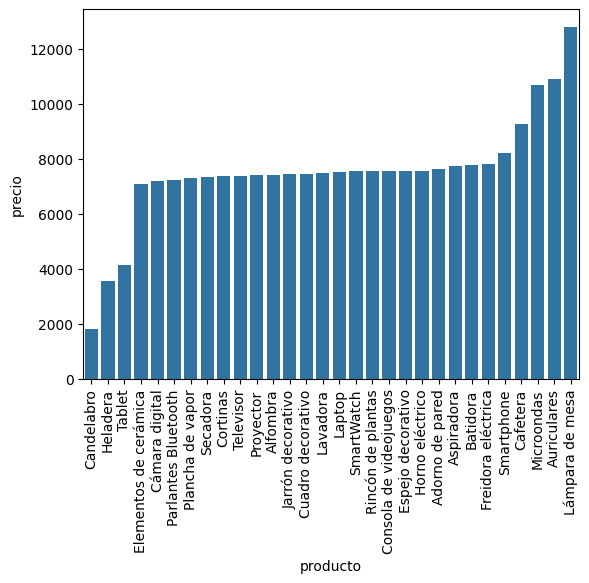

In [35]:
# Opcional: para visualizar algo:
import matplotlib.pyplot as plt
import seaborn as sns
df_ven_agg = df_ven_agg.sort_values(by="precio", ascending=True)
sns.barplot(x="producto", y="precio", data=df_ven_agg)
plt.xticks(rotation=90)
plt.show()

In [36]:
# Otro enfoque de agregaciones más completa:
df_ven_agg1 = df_ven_pp.groupby(["producto"], as_index=False).agg(
    sum_ventas=("precio", "sum"),
    count_ventas=("cantidad", "sum"),
    avg_ventas=("precio", "mean")
)
df_ven_agg1 = df_ven_agg1.sort_values(by="count_ventas", ascending=True)


In [37]:
quantile_90 = df_ven_agg1["count_ventas"].quantile(0.9)
quantile_90

np.float64(779.7000000000002)

In [38]:
alto_rendimiento_agg1 = df_ven_agg1[df_ven_agg1["count_ventas"] > quantile_90]
alto_rendimiento_agg1.sort_values(by="count_ventas", ascending=False).head()

,producto,sum_ventas,count_ventas,avg_ventas
19,Lámpara de mesa,12798.83,1112,72.720625
3,Auriculares,10911.29,958,76.302727
20,Microondas,10688.76,912,79.176000


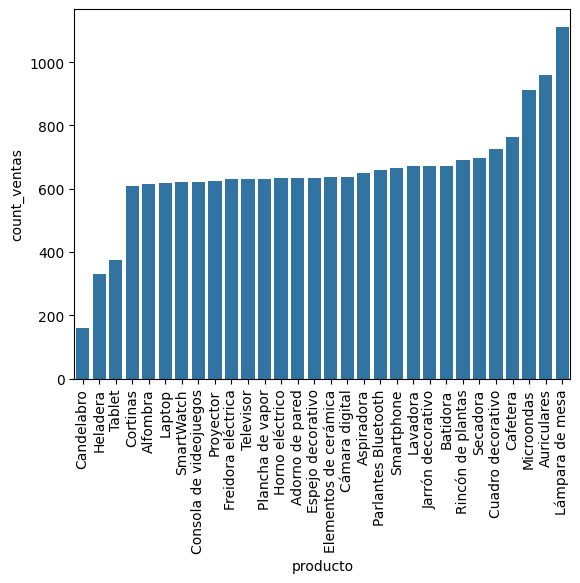

In [39]:
sns.barplot(x="producto", y="count_ventas", data=df_ven_agg1)
plt.xticks(rotation=90)
plt.show()

#2.3 - Agregación:
### Resumir las ventas por categoría de producto y analizar los ingresos generados.

In [40]:
#Veamos las categorías únicas.
df_ven_pp["categoria"].unique()
df_ven_pp["categoria"].nunique()
df_ven_pp["categoria"].value_counts()

,count
categoria,
Decoración,1000
Electrodomésticos,1000
Electrónica,998


In [41]:
# Resumir ventas e ingresos por categoría
resumen_categorias = df_ven_pp.groupby('categoria').agg(total_unidades_vendidas=('cantidad', 'sum'),
ingresos_totales_generados=('precio', 'sum'),transacciones=('id_venta', 'count')).sort_values(by='ingresos_totales_generados', ascending=False)
print("Resumen de ventas por categoría:")
print(resumen_categorias.to_string())
print("\n")

Resumen de ventas por categoría:
                   total_unidades_vendidas  ingresos_totales_generados  transacciones
categoria                                                                            
Electrodomésticos                     6592                    76520.96           1000
Electrónica                           6413                    75104.41            998
Decoración                            6490                    74098.00           1000




Sobre el error que te apareció de la agregación: CORREGIDO EL ERROR!!!: Sustituí el nombre de la columna "ingresos_totales" el cual no existe en el DF_ventas por el nombre de la columna "precio", el cual si existe en el dataframe antes mencionado.

### Resumir ventas e ingresos por categoría
resumen_categorias = df_ven_pp.groupby('categoria')
.agg(
    total_unidades_vendidas=('cantidad', 'sum'),
    ingresos_totales_generados=('ingresos_totales', 'sum'),
    transacciones=('id_venta', 'count'))
.sort_values(by='ingresos_totales_generados', ascending=False)
print("Resumen de ventas por categoría:")
print(resumen_categorias.to_string())
print("\n")

Es porque estas queriendo ordenar por una columna que no existe, en este caso tiene que ser algunas de las que generaste en la agregación o "producto" que usaste para agrupar.

#2.4- Integración de Datos:
###Combinar los sets de datos de ventas y marketing para obtener una visión más amplia de las tendencias.

In [42]:
df_mar_pp.head(2)

,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
0,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03
1,12,Tablet,RRSS,3.40,2024-03-26,2024-05-13


In [43]:
#Ordenamos el dataframe mar_pp, según los campos.
df_mar_pp.sort_values(by=["id_campanha","producto","canal"])
#, as_index=false)["costo"].sum().sort_values(by=["producto", "canal"])

,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
10,1,Cuadro decorativo,RRSS,5.27,2024-04-27,2024-06-04
21,2,Lámpara de mesa,RRSS,5.88,2024-05-30,2024-06-29
40,3,Secadora,RRSS,5.10,2024-07-24,2024-08-30
22,4,Heladera,RRSS,4.53,2024-05-31,2024-07-15
54,5,Horno eléctrico,RRSS,5.16,2024-08-22,2024-10-17
...,...,...,...,...,...,...
64,86,Microondas,TV,4.25,2024-09-25,2024-11-15
56,87,Batidora,TV,6.28,2024-08-27,2024-10-11
41,88,Alfombra,TV,7.39,2024-07-25,2024-08-31
86,89,Televisor,TV,4.98,2024-12-13,2025-02-08


In [44]:
#Ahora lo agrupamos por esos mismos campos:
df_mar_pp.groupby(["id_campanha","producto","canal"], as_index=False)["costo"].sum().sort_values(by=["producto","canal"])

,id_campanha,producto,canal,costo
43,44,Adorno de pared,Email,5.08
13,14,Adorno de pared,RRSS,4.16
73,74,Adorno de pared,TV,4.81
57,58,Alfombra,Email,4.25
27,28,Alfombra,RRSS,5.82
...,...,...,...,...
11,12,Tablet,RRSS,3.40
71,72,Tablet,TV,4.90
58,59,Televisor,Email,4.19
28,29,Televisor,RRSS,3.96


In [45]:
# Agrupar las ventas por producto para poder comparar con marketing
df_ventas_por_producto = df_ven_pp.groupby('producto').agg(ingresos_producto=('precio', 'sum'), unidades_producto=('cantidad', 'sum')).reset_index()

In [46]:
# Combinar (Merge) con el set de datos de marketing por la columna 'producto'
df_integrado = pd.merge(df_mar_pp, df_ventas_por_producto, on='producto', how='inner')
print("Muestra del set de datos integrado (Primeras 5 filas):")
print(df_integrado[['id_campanha', 'producto', 'canal', 'costo', 'ingresos_producto']].head())

Muestra del set de datos integrado (Primeras 5 filas):
   id_campanha         producto  canal  costo  ingresos_producto
0           74  Adorno de pared     TV   4.81            7609.78
1           12           Tablet   RRSS   3.40            4140.19
2           32  Lámpara de mesa  Email   5.54           12798.83
3           21       Smartphone   RRSS   6.37            8221.24
4           58         Alfombra  Email   4.25            7409.83


# ETAPA 3: Análisis de Datos

In [47]:
#3.1- Estadística Descriptiva: Calcular medidas de tendencia central (media, mediana, moda)
#y dispersión (desviación estándar, rango intercuartílico) sobre las ventas.

print("=== ETAPA 3.1: ESTADÍSTICA DESCRIPTIVA sobre las ventas ===")
media = df_ven_pp['precio'].mean()
mediana = df_ven_pp['precio'].median()
moda = df_ven_pp['precio'].mode()[0]
std_dev = df_ven_pp['precio'].std()
q1 = df_ven_pp['precio'].quantile(0.25)
q3 = df_ven_pp['precio'].quantile(0.75)
iqr = q3 - q1

print(f"Media: ${media:.2f}")
print(f"Mediana: ${mediana:.2f}")
print(f"Moda: ${moda:.2f}")
print(f"Desviación Estándar: ${std_dev:.2f}")
print(f"Rango Intercuartílico (IQR): ${iqr:.2f}\n")

=== ETAPA 3.1: ESTADÍSTICA DESCRIPTIVA sobre las ventas ===
Media: $75.29
Mediana: $75.20
Moda: $29.77
Desviación Estándar: $28.74
Rango Intercuartílico (IQR): $50.04



In [48]:
#3.2- EDA (Análisis Exploratorio de Datos): Realizar un análisis estadístico de los datos para identificar
#patrones, tendencias y anomalías en las ventas (opcional en costos de marketing).
# 2. EDA: Ventas por Categoría:
print("=== ETAPA 3.2: EDA (Ventas por Categoría) ===")
cat_summary = df_ven_pp.groupby('categoria')['precio'].agg(['sum', 'count', 'mean']).reset_index()
print(cat_summary, "\n")

=== ETAPA 3.2: EDA (Ventas por Categoría) ===
           categoria       sum  count      mean
0         Decoración  74098.00   1000  74.09800
1  Electrodomésticos  76520.96   1000  76.52096
2        Electrónica  75104.41    998  75.25492 



=== ETAPA 3.3: MATRIZ DE CORRELACIÓN ===
          cantidad    precio
cantidad  1.000000 -0.002388
precio   -0.002388  1.000000 



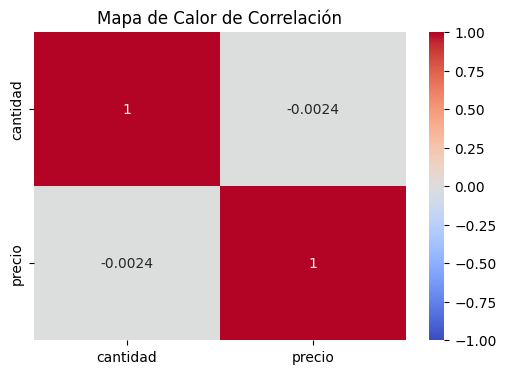

In [49]:
#3.3- Correlación: Evaluar la relación entre diferentes variables (por ejemplo, precio y cantidad vendida)
#y mostrar los resultados en un mapa de calor.
print("=== ETAPA 3.3: MATRIZ DE CORRELACIÓN ===")
corr_matrix = df_ven_pp[['cantidad', 'precio']].corr()
print(corr_matrix, "\n")

# Mapa de calor de correlación:
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Mapa de Calor de Correlación')
plt.show()

In [50]:
#3.4 Consolidación de Datos: De la integración ventas - marketing, elija al menos un enfoque de análisis, por ejemplo, comparar ventas
#de productos dentro y fuera de campaña y obtener el dataframe con todos los datos para generar las visualizaciones.
# Cruzamos por producto, y verificamos si la fecha de venta cae dentro del rango de campaña.
df_joined = df_ven_pp.merge(df_mar_pp, on='producto', how='left')

# Condición: si no hay campaña asignada, es False. Si hay, verificamos si la fecha coincide.
df_joined['en_campanha'] = (df_joined['fecha_venta'] >= df_joined['fecha_inicio']) & (df_joined['fecha_venta'] <= df_joined['fecha_fin'])
df_joined['en_campanha'] = df_joined['en_campanha'].fillna(False)

# Agrupamos para obtener el DataFrame consolidado final eliminando duplicados de cruce por fila
df_consolidado = df_joined.groupby(['id_venta', 'producto', 'categoria', 'precio', 'fecha_venta'])['en_campanha'].any().reset_index()

print("=== ETAPA 3.4: CONSOLIDACIÓN (Muestra del DataFrame) ===")
print(df_consolidado.head(), "\n")

=== ETAPA 3.4: CONSOLIDACIÓN (Muestra del DataFrame) ===
   id_venta           producto   categoria  precio fecha_venta  en_campanha
0         1    Lámpara de mesa  Decoración   82.25  2024-04-17         True
1         2  Cuadro decorativo  Decoración  106.12  2024-02-27        False
2         3  Espejo decorativo  Decoración   51.32  2024-09-22         True
3         4  Jarrón decorativo  Decoración   64.12  2024-11-01        False
4         5           Alfombra  Decoración   70.10  2024-11-02        False 



#ETAPA 4: VISUALIZACIÓN DE DATOS

/tmp/ipykernel_555/543724924.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='categoria', y='precio', data=df_ven_pp, ax=axes[1], palette='Set2')


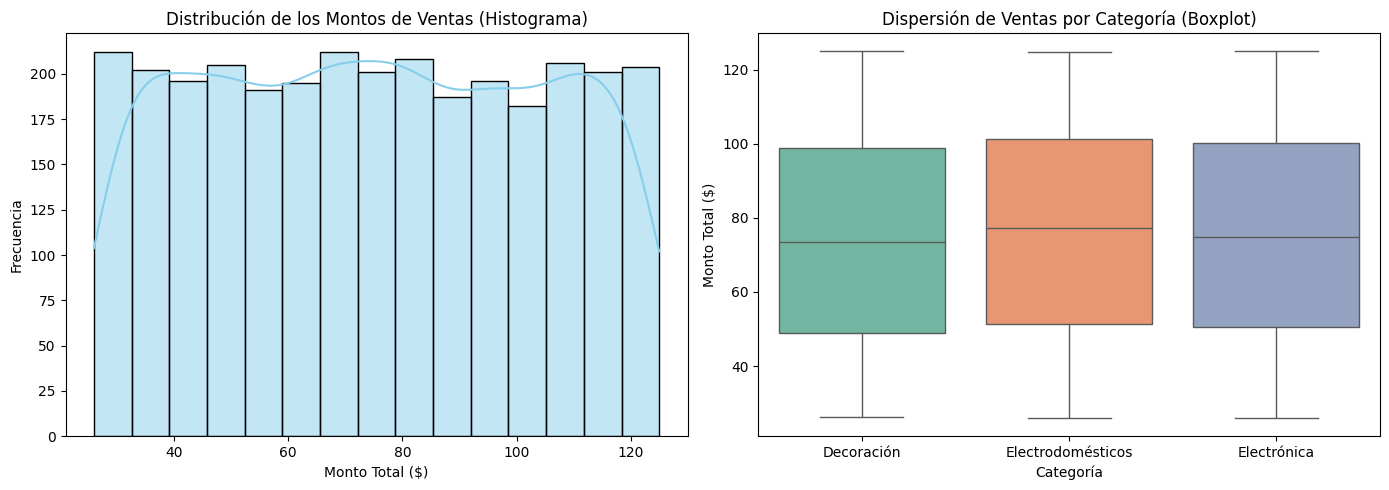

In [51]:
# 4.1- Visualización con seaborn: Generar un gráfico de histogramas y boxplots de las variables de interés.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_ven_pp['precio'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de los Montos de Ventas (Histograma)')
axes[0].set_xlabel('Monto Total ($)')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(x='categoria', y='precio', data=df_ven_pp, ax=axes[1], palette='Set2')
axes[1].set_title('Dispersión de Ventas por Categoría (Boxplot)')
axes[1].set_xlabel('Categoría')
axes[1].set_ylabel('Monto Total ($)')

plt.tight_layout()
plt.show()

In [52]:
#4.2- Visualización con Plotly o Altair: Generar una visualización interactiva de la consolidación de los datos.
#Visualización Interactiva con Plotly (Consolidación)
df_plotly = df_consolidado.groupby('en_campanha')['precio'].sum().reset_index()
df_plotly['en_campanha'] = df_plotly['en_campanha'].map({True: 'En Campaña', False: 'Fuera de Campaña'})

fig_plotly = px.bar(
    df_plotly,
    x='en_campanha',
    y='precio',
    color='en_campanha',
    title='Impacto de las Campañas de Marketing en la Facturación Total',
    labels={'total_venta': 'Ventas Totales ($)', 'en_campanha': 'Estado de Venta'},
    text_auto='.2s'
)
fig_plotly.show()

# Fin del Ejercicio.
### Es de hacer notar que en el Colab (en mi computadora) donde hice mi ejercicio de entrega  final, el gráfico del punto: 4.2 (el último punto) Si se visualiza. Pero No se refleja cuando guardo la copia aquí en Github.